# Collecting Data - Preprocessing and Data Acquisition Test
This notebook tests the classes for data acquisition, technical indicator calculation, and preprocessing.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path

# Add project root to path
sys.path.append(str(Path.cwd().parent))

from Collecting_Data.mt5data import MT5DataLoader
from Collecting_Data.Price import YFinanceDataLoader
from Collecting_Data.preproc_single_inout import SingleInOutPreprocessor
from Collecting_Data.preproc_multi_inout import MultiInOutPreprocessor
from Collecting_Data.preproc_pivot import PivotPreprocessor
from Collecting_Data.indicators import IndicatorEngine
from Collecting_Data.logging_config import setup_logging

# Setup logging for the notebook session
setup_logging(log_dir="../logs")


## 3. Test Indicator Engine (indicators.py)


In [2]:
# Create a dummy dataset for quick testing if real data is missing
n = 1000
np.random.seed(42)
prices = 1.2500 + np.cumsum(np.random.randn(n) * 0.0002)
df_dummy = pd.DataFrame({
    'Datetime': pd.date_range('2024-01-01', periods=n, freq='5min'),
    'Open': prices + np.random.randn(n) * 0.0001,
    'High': prices + np.abs(np.random.randn(n)) * 0.0003,
    'Low': prices - np.abs(np.random.randn(n)) * 0.0003,
    'Close': prices,
    'TickVolume': np.random.randint(100, 1000, n),
    'Spread': np.zeros(n)
})

engine = IndicatorEngine(dropna=True)
df_enriched = engine.calculate(df_dummy)
print(f"Enriched data shape: {df_enriched.shape}")
display(df_enriched.head(10))


2026-06-19 13:03:02,193 [INFO] IndicatorEngine: Dropped 0 rows containing NaN in EMA or ATR columns.


Enriched data shape: (1000, 32)


,Datetime,Open,High,Low,Close,TickVolume,Spread,ema_21,ema_50,ema_600,...,dist_ema_21,cross_ema_21,ema_span_21,dist_ema_50,cross_ema_50,ema_span_50,dist_ema_600,cross_ema_600,ema_span_600,ema_slope_600
0,2024-01-01 00:00:00,1.250239,1.250302,1.249527,1.250099,662,0.0,1.250099,1.250099,1.250099,...,0.000000,0,1,0.000000,0,1,0.000000,0,1,NaN
1,2024-01-01 00:05:00,1.250164,1.250115,1.249814,1.250072,365,0.0,1.250097,1.250098,1.250099,...,-0.033922,0,1,-0.035851,0,1,-0.037190,0,1,NaN
2,2024-01-01 00:10:00,1.250207,1.250439,1.250077,1.250201,219,0.0,1.250106,1.250102,1.250100,...,0.132854,1,1,0.138486,1,1,0.142274,1,1,NaN
3,2024-01-01 00:15:00,1.250441,1.250598,1.249940,1.250506,811,0.0,1.250143,1.250118,1.250101,...,0.511253,0,1,0.545765,0,1,0.569948,0,1,NaN
4,2024-01-01 00:20:00,1.250529,1.251027,1.250292,1.250459,347,0.0,1.250171,1.250131,1.250102,...,0.403846,0,0,0.459887,0,0,0.501107,0,0,NaN
5,2024-01-01 00:25:00,1.250452,1.250476,1.250012,1.250412,169,0.0,1.250193,1.250142,1.250103,...,0.315181,0,1,0.388317,0,1,0.444951,0,1,NaN
6,2024-01-01 00:30:00,1.250818,1.250728,1.250582,1.250728,952,0.0,1.250242,1.250165,1.250105,...,0.728309,0,0,0.842835,0,0,0.933048,0,0,NaN
7,2024-01-01 00:35:00,1.250945,1.251127,1.250417,1.250882,156,0.0,1.250300,1.250194,1.250108,...,0.867266,0,0,1.026125,0,0,1.153965,0,0,NaN
8,2024-01-01 00:40:00,1.250893,1.250985,1.250463,1.250788,481,0.0,1.250344,1.250217,1.250110,...,0.671689,0,0,0.864956,0,0,1.026718,0,0,NaN
9,2024-01-01 00:45:00,1.250843,1.251177,1.250755,1.250896,138,0.0,1.250395,1.250243,1.250113,...,0.780155,0,0,1.015099,0,0,1.218490,0,0,NaN


### 3.1 Visualization of New Indicators


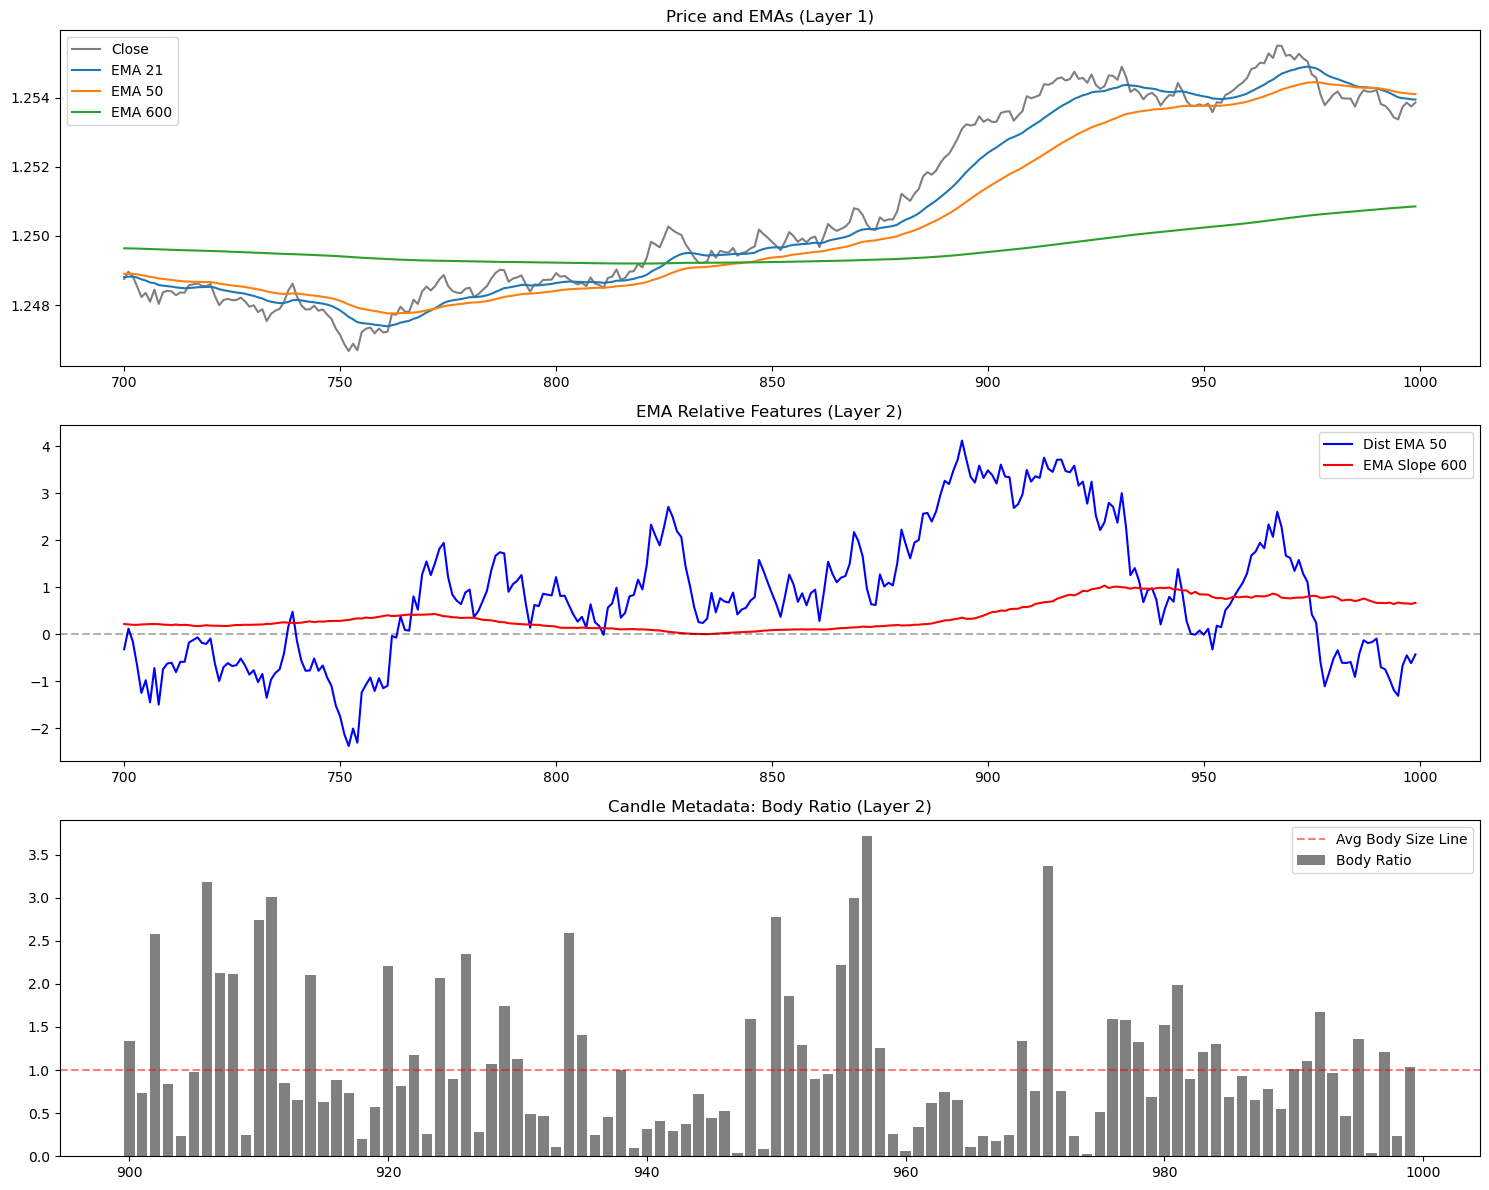

In [3]:
plt.figure(figsize=(15, 12))

# Subplot 1: Price and EMAs
plt.subplot(3, 1, 1)
plt.plot(df_enriched['Close'].tail(300), label='Close', color='black', alpha=0.5)
plt.plot(df_enriched['ema_21'].tail(300), label='EMA 21')
plt.plot(df_enriched['ema_50'].tail(300), label='EMA 50')
plt.plot(df_enriched['ema_600'].tail(300), label='EMA 600')
plt.title('Price and EMAs (Layer 1)')
plt.legend()

# Subplot 2: EMA Distance and Slope
plt.subplot(3, 1, 2)
plt.plot(df_enriched['dist_ema_50'].tail(300), label='Dist EMA 50', color='blue')
plt.plot(df_enriched['ema_slope_600'].tail(300), label='EMA Slope 600', color='red')
plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.title('EMA Relative Features (Layer 2)')
plt.legend()

# Subplot 3: Candle Metadata (Body Ratio)
plt.subplot(3, 1, 3)
plt.bar(df_enriched.tail(100).index, df_enriched['body_vs_avg'].tail(100), label='Body Ratio', color='gray')
plt.axhline(1.0, color='red', linestyle='--', alpha=0.5, label='Avg Body Size Line')
plt.title('Candle Metadata: Body Ratio (Layer 2)')
plt.legend()

plt.tight_layout()
plt.show()


## 2. Test Data Loaders (mt5data.py & Price.py)


In [4]:
# Test YFinanceDataLoader
yf_loader = YFinanceDataLoader()
yf_df = yf_loader.download_data(period='1mo', interval='1h')
if yf_df is not None:
    print("YFinance data downloaded successfully.")
    display(yf_df.head())

# Test MT5DataLoader (Requires MT5 Terminal and credentials)
print("\nTesting MT5DataLoader (Mocked initialization test)...")
mt5_loader = MT5DataLoader()
print("MT5DataLoader initialized. (Real connection requires MT5 terminal)")


[*********************100%***********************]  1 of 1 completed

Data saved to C:\Users\MHossein\Documents\GitHub\Forex_DNN\Data\GBPUSD_1h.csv
YFinance data downloaded successfully.


Price,Datetime,Close,High,Low,Open,Volume
0,2026-05-19 09:00:00+00:00,1.340842,1.340842,1.338814,1.339262,0
1,2026-05-19 10:00:00+00:00,1.340680,1.341526,1.339567,1.340698,0
2,2026-05-19 11:00:00+00:00,1.340483,1.340932,1.340357,1.340680,0
3,2026-05-19 12:00:00+00:00,1.340932,1.341850,1.340375,1.340483,0
4,2026-05-19 13:00:00+00:00,1.340429,1.340788,1.338849,1.340788,0



Testing MT5DataLoader (Mocked initialization test)...
MT5DataLoader initialized. (Real connection requires MT5 terminal)


## 3. Test Preprocessors


In [5]:
# 3.1 SingleInOutPreprocessor
print("Testing SingleInOutPreprocessor...")
preproc_s = SingleInOutPreprocessor()
df_s = preproc_s.preprocess("GBPUSD_1h.csv")
if df_s is not None:
    print(f"Single InOut shape: {df_s.shape}")
    display(df_s.head())

# 3.2 MultiInOutPreprocessor
print("\nTesting MultiInOutPreprocessor...")
preproc_m = MultiInOutPreprocessor()
X, y = preproc_m.preprocess("GBPUSD_1h.csv", num_input_candles=24, num_output_candles=1)
if X is not None:
    print(f"Multi InOut shapes - X: {X.shape}, y: {y.shape}")

# 3.3 PivotPreprocessor
print("\nTesting PivotPreprocessor...")
preproc_p = PivotPreprocessor()
df_p = preproc_p.preprocess("GBPUSD_1h.csv")
if df_p is not None:
    print(f"Pivot data shape: {df_p.shape}")


2026-06-19 13:03:05,676 [WARNING] IndicatorEngine: Input DataFrame has fewer rows (549) than warmup requirement (632). Indicators may not be fully warmed up.
2026-06-19 13:03:05,691 [INFO] IndicatorEngine: Dropped 0 rows containing NaN in EMA or ATR columns.


Testing SingleInOutPreprocessor...
Single InOut shape: (516, 35)


,Open,High,Low,Close,Vol,TickVolume,Spread,ema_21,ema_50,ema_600,...,dist_ema_50,cross_ema_50,ema_span_50,dist_ema_600,cross_ema_600,ema_span_600,ema_slope_600,Price_Change,Binary_Label,Multi_Label
32,1.344122,1.344574,1.343671,1.343671,0,0,0,1.340863,1.340521,1.340776,...,1.789318,0,0,1.644844,0,0,0.037757,0.000957,1,3
33,1.343364,1.344936,1.343364,1.344628,0,0,0,1.341206,1.340682,1.340788,...,2.259056,0,0,2.198336,0,0,0.030399,-0.000741,0,1
34,1.344321,1.344827,1.343887,1.343887,0,0,0,1.341449,1.340808,1.340799,...,1.823090,0,0,1.828605,0,0,0.024624,-0.000361,0,1
35,1.343815,1.344068,1.343436,1.343526,0,0,0,1.341638,1.340915,1.340808,...,1.618472,0,0,1.684681,0,0,0.020340,0.000271,1,3
36,1.344068,1.344429,1.343580,1.343797,0,0,0,1.341834,1.341028,1.340818,...,1.772065,0,0,1.906387,0,0,0.013758,-0.000054,0,2


2026-06-19 13:03:05,708 [WARNING] IndicatorEngine: Input DataFrame has fewer rows (549) than warmup requirement (632). Indicators may not be fully warmed up.
2026-06-19 13:03:05,724 [INFO] IndicatorEngine: Dropped 0 rows containing NaN in EMA or ATR columns.



Testing MultiInOutPreprocessor...


2026-06-19 13:03:06,046 [WARNING] IndicatorEngine: Input DataFrame has fewer rows (549) than warmup requirement (632). Indicators may not be fully warmed up.
2026-06-19 13:03:06,061 [INFO] IndicatorEngine: Dropped 0 rows containing NaN in EMA or ATR columns.


Multi InOut shapes - X: (525, 24, 32), y: (525, 1)

Testing PivotPreprocessor...
Pivot data shape: (525, 36)


## 4. Visualizing Features


2026-06-19 13:03:06,084 [WARNING] IndicatorEngine: Input DataFrame has fewer rows (549) than warmup requirement (632). Indicators may not be fully warmed up.
2026-06-19 13:03:06,101 [INFO] IndicatorEngine: Dropped 0 rows containing NaN in EMA or ATR columns.


Pivot data shape: (525, 36)


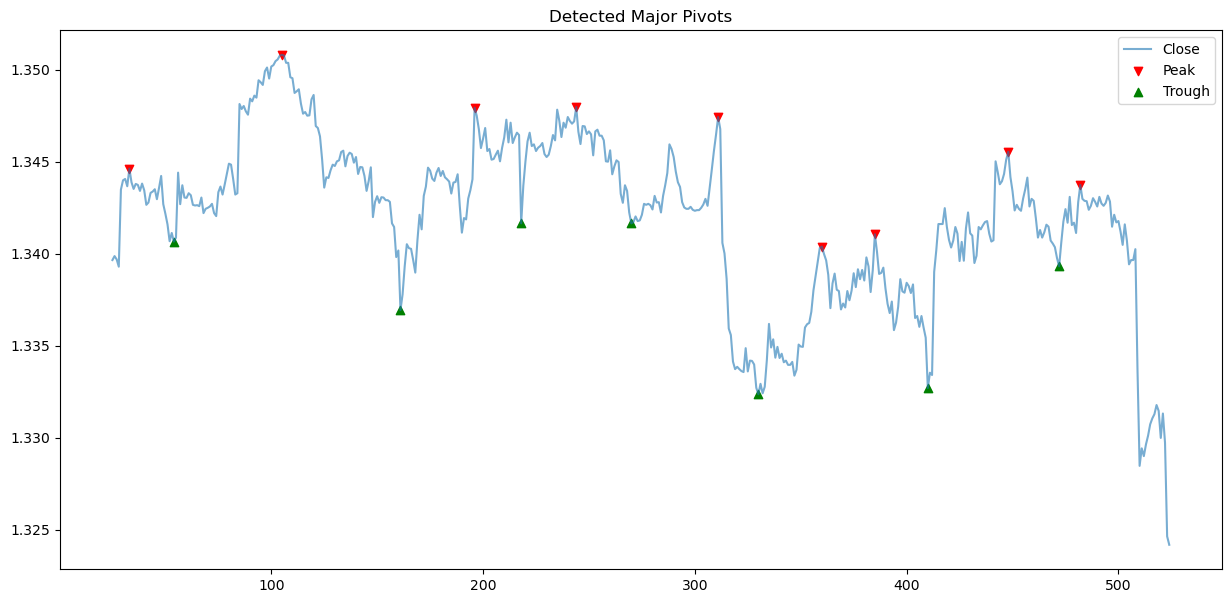

In [6]:
# Test PivotPreprocessor
pivot_preproc = PivotPreprocessor()
df_pivot = pivot_preproc.preprocess("GBPUSD_1h.csv")
if df_pivot is not None:
    print(f"Pivot data shape: {df_pivot.shape}")

    # Plot Pivots
    sample = df_pivot.tail(500)
    plt.figure(figsize=(15, 7))
    plt.plot(sample['Close'], label='Close', alpha=0.6)
    plt.scatter(sample[sample['Peak']==1].index, sample[sample['Peak']==1]['Close'], color='red', label='Peak', marker='v')
    plt.scatter(sample[sample['Trough']==1].index, sample[sample['Trough']==1]['Close'], color='green', label='Trough', marker='^')
    plt.title("Detected Major Pivots")
    plt.legend()
    plt.show()
else:
    print("Error: Pivot preprocessing failed (possibly file not found).")
